The **probability of nth recall** (PNR) analysis examines which studied items, by their serial position, end up as the *n*-th recalled item.

- `fixed_pres_pnr` assumes uniform study lists (no item repetitions). It simply tallies which item was recalled in the *n*-th position across trials.
- `var_pres_pnr` handles study lists with repetitions by accounting for every position an item could have occupied.

Both helpers can be wrapped with JAX transforms like `jit` or `vmap` to accelerate batch analyses, but the plotting helper below keeps the interface simple for automated reporting.

In [1]:
import matplotlib.pyplot as plt
import os
import warnings

from jaxcmr.analyses.pnr import plot_pnr
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")

def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()


In [2]:
run_tag = "PNR"
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['list_type'] == 1"
query_recall_position = 0


In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)


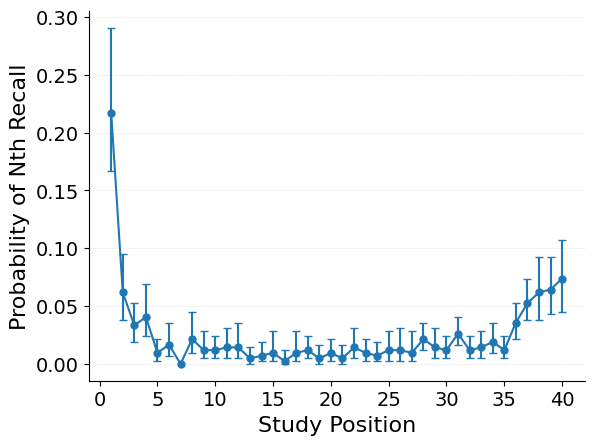

In [4]:
plot_pnr(data, trial_mask, query_recall_position=query_recall_position);
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)
